## Introduction: 
This project utilizes two datasets sourced from Kaggle: the Breast Cancer dataset and the Digits dataset. For the Breast Cancer dataset, which consists of diagnostic data on tumors labeled as either benign or malignant, I will apply binomial logistic regression since it involves two possible outcome categories. The dataset includes various features extracted from digitized images of fine needle aspirates (FNA) of breast masses, such as radius, texture, perimeter, area, and smoothness.

In contrast, the Digits dataset contains images of handwritten digits with more than three possible categories. For this dataset, I will perform multinomial logistic regression to classify the digits accurately. Additionally, I will explore feature importance and model performance using decision trees to complement the logistic regression results.

The primary objective of this project is to develop predictive models that accurately classify breast tumors as malignant or benign, as well as correctly identify handwritten digits. Through exploratory data analysis and the application of machine learning techniques, including logistic regression.The project aims to evaluate model effectiveness and identify the most influential features for both cancer diagnosis and digit recognition.

In [192]:
# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1- Breast Cancer Dataset

## Binomial Logistic Regression

### Data Exploration

In [105]:
# Load the breast cancer data from kaggle and read it.
breast_cancer_data = pd.read_csv(r"C:\Users\thier\OneDrive\Desktop\ML data\breast-cancer.csv")
# Show the first 5 rows of the data
breast_cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [106]:
# Show general info of the data
breast_cancer_data.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Columns: 32 entries, id to fractal_dimension_worst
dtypes: float64(30), int64(1), object(1)
memory usage: 142.4+ KB


In [107]:
# See the shape of the data
breast_cancer_data.shape

(569, 32)

In [108]:
# Diplay statistical analysis of the data
breast_cancer_data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Data Preprocessing

In [110]:
# Check for missing values
breast_cancer_data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [111]:
# Check for duplicates rows
breast_cancer_data.duplicated().sum()

0

In [112]:
# Summary : 
# no null values, no duplicate, 
breast_cancer_data.diagnosis.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [113]:
# Check for possible outlier in the data
# Retrieve categorical column from the breast cancer data
categorical_col = ['diagnosis']
# Turn it into a categorical value True/False
breast_cancer_data_encoded = pd.get_dummies(breast_cancer_data, columns=categorical_col, drop_first=True)
# Show first 5 rows of the data
breast_cancer_data_encoded.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,True
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,True
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,True
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,True
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,True


In [114]:
# Imports the IsolationForest model from scikit-learn.
# Which is an unsupervised anomaly detection algorithm.
# It works by isolating anomalies instead of profiling normal data. Hence, uutliers are more easily separated (isolated) than normal points
from sklearn.ensemble import IsolationForest

# Creates a new Isolation Forest model with a threshold of 0.05. 
# This tells the model we expect ~5% of the data to be outliers.
model = IsolationForest(contamination=0.05)

# Fits the Isolation Forest model to your data (excluding the target column: 'price')
# Creates a new column called 'outlier' in the DataFrame with the prediction results.
breast_cancer_data_encoded['outlier'] = model.fit_predict(breast_cancer_data_encoded.drop('diagnosis_M', axis=1))

# Filter and show only rows that contain outliers
breast_cancer_with_outlier = breast_cancer_data_encoded[breast_cancer_data_encoded['outlier'] == -1]
breast_cancer_with_outlier

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M,outlier
0,842302,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,True,-1
3,84348301,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,True,-1
9,84501001,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,True,-1
12,846226,19.170,24.80,132.40,1123.0,0.09740,0.24580,0.20650,0.11180,0.2397,...,151.70,1332.0,0.1037,0.3903,0.3639,0.17670,0.3176,0.10230,True,-1
42,855625,19.070,24.81,128.30,1104.0,0.09081,0.21900,0.21070,0.09961,0.2310,...,177.40,1651.0,0.1247,0.7444,0.7242,0.24930,0.4670,0.10380,True,-1
68,859471,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,...,65.50,324.7,0.1482,0.4365,1.2520,0.17500,0.4228,0.11750,False,-1
71,859711,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,...,62.56,284.4,0.1207,0.2436,0.1434,0.04786,0.2254,0.10840,False,-1
78,8610862,20.180,23.97,143.70,1245.0,0.12860,0.34540,0.37540,0.16040,0.2906,...,170.30,1623.0,0.1639,0.6164,0.7681,0.25080,0.5440,0.09964,True,-1
82,8611555,25.220,24.91,171.50,1878.0,0.10630,0.26650,0.33390,0.18450,0.1829,...,211.70,2562.0,0.1573,0.6076,0.6476,0.28670,0.2355,0.10510,True,-1
108,86355,22.270,19.67,152.80,1509.0,0.13260,0.27680,0.42640,0.18230,0.2556,...,206.80,2360.0,0.1701,0.6997,0.9608,0.29100,0.4055,0.09789,True,-1


In [115]:
breast_cancer_no_outlier = breast_cancer_data_encoded[breast_cancer_data_encoded['outlier'] == 1]
breast_cancer_no_outlier

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M,outlier
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,True,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,True,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,True,1
5,843786,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,103.40,741.6,0.17910,0.52490,0.5355,0.1741,0.3985,0.12440,True,1
6,844359,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,153.20,1606.0,0.14420,0.25760,0.3784,0.1932,0.3063,0.08368,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,926125,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,0.2149,...,179.10,1819.0,0.14070,0.41860,0.6599,0.2542,0.2929,0.09873,True,1
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,True,1
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,True,1
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,True,1


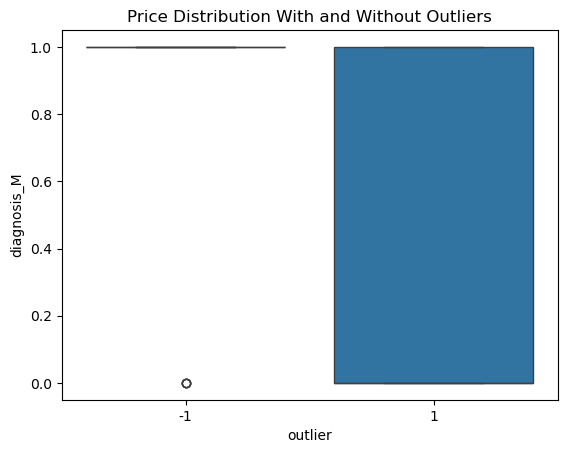

In [116]:
# Visualize outlier vs no outlier
sns.boxplot(data=breast_cancer_data_encoded, x='outlier', y='diagnosis_M')
plt.title("Price Distribution With and Without Outliers")
plt.show()

In [117]:
# Display distribution for both groups: 
print(breast_cancer_data_encoded.groupby('outlier')['diagnosis_M'].value_counts(normalize=True))


outlier  diagnosis_M
-1       True           0.862069
         False          0.137931
 1       False          0.653704
         True           0.346296
Name: proportion, dtype: float64


In [118]:
breast_cancer_data_encoded

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M,outlier
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,True,-1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,True,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,True,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,True,-1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,True,1
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,True,1
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,True,1
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,True,-1


### Summary after checking outlier
1. number_rows_outlier = 29
2. total_number_of_rows = 569
3. ratio = number_rows_outlier / total_number_of_rows
4. ratio * 100 = 5.1%
5. Non-outlier are about : 94.9% of the data
6. dataset is mostly normal data, with a small fraction of outliers.

#### Performing the breast cancer data with outlier using Logistic regression

In [121]:
# Import logistic regression from sklearn.linear_model
from sklearn.linear_model import LogisticRegression

In [122]:
# Initializing X and y 
X_1 = breast_cancer_data_encoded.drop(columns=['diagnosis_M', 'outlier'], axis=1)
y_1 = breast_cancer_data_encoded['diagnosis_M']

In [123]:
from sklearn.model_selection import train_test_split
# Split data into training and testing 
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

In [124]:
# Create an instance from the logistic regression class
model_1 = LogisticRegression()
# Fit the model
model_1.fit(X_1_train, y_1_train)

LogisticRegression()

In [125]:
from sklearn.metrics import accuracy_score
# Show the accuracy of the model
acc = accuracy_score(y_1_test, model_1.predict(X_1_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 95.61%


In [126]:
# Let evaluate a prediction to our model
y_pred_1 = model_1.predict(X_1_test)

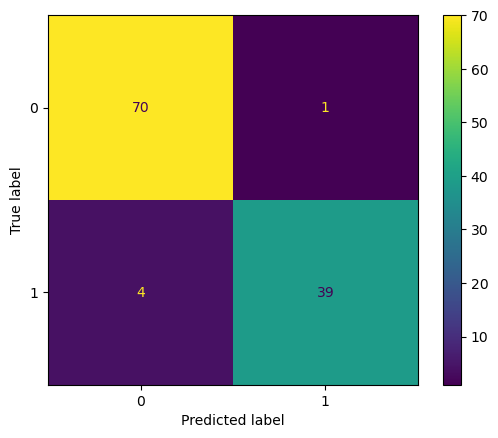

In [127]:
# Visualize a confusion matrix of the result
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_1_test, y_pred_1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

#### 0 - Begnin and 1 - Malignan
#### Truth negative = 70
#### False negative = 4
#### False positive = 1
#### True positive = 39

In [129]:
# Let’s compute a few useful evaluation metrics using the numbers:

# Accuracy = (TP + TN) / Total 
Accuracy = (39 + 70) / (70 + 4 + 1 + 39)
print(f"Accuracy is: {Accuracy}")

# Precision (Positive Predictive Value) = TP / (TP + FP) 
Precision = 39 / (39 + 1) 
print(f"Precision is: {Precision}")

# Recall (Sensitivity) = TP / (TP + FN) 
Recall = 39 / (39 + 4) 
print(f"Recall is: {Recall}")

# F1_Score = 2 * (Precision * Recall) / (Precision + Recall) 
F1_Score = 2 * (Precision * Recall) / (Precision + Recall)
print(f"F1 Score is: {F1_Score}")


Accuracy is: 0.956140350877193
Precision is: 0.975
Recall is: 0.9069767441860465
F1 Score is: 0.9397590361445783


In [130]:
# Classification report:
from sklearn.metrics import classification_report
print(classification_report(y_1_test, y_pred_1))

              precision    recall  f1-score   support

       False       0.95      0.99      0.97        71
        True       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



#### Performing the breast cancer data without outlier using Logistic regression

In [132]:
# Initialize X and y 
X_2 = breast_cancer_no_outlier.drop(columns=['diagnosis_M', 'outlier'], axis=1)
y_2 = breast_cancer_no_outlier['diagnosis_M']

In [133]:
# Creating the training and testing data
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

In [134]:
# Creating an instance of the logistic regression class
model_2 = LogisticRegression()
# Fit the model on the training data
model_2.fit(X_2_train, y_2_train)

C:\Users\thier\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [135]:
# Evaluate a prediction of the model
y_pred_2 = model_2.predict(X_2_test)

In [136]:
# Show the accuracy of the model
acc_2 = accuracy_score(y_2_test, model_2.predict(X_2_test)) * 100
print(f"Logistic Regression model accuracy: {acc_2:.2f}%")

Logistic Regression model accuracy: 88.89%


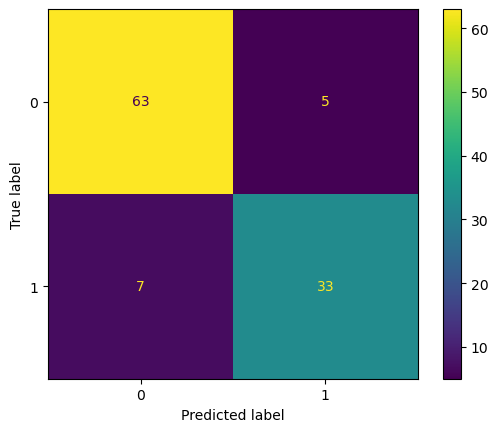

In [137]:
# Visualizing the confusion matrix
cm_2 = confusion_matrix(y_2_test, y_pred_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_2)
disp.plot()

In [138]:
# Classification report:
print(classification_report(y_2_test, y_pred_2))

              precision    recall  f1-score   support

       False       0.90      0.93      0.91        68
        True       0.87      0.82      0.85        40

    accuracy                           0.89       108
   macro avg       0.88      0.88      0.88       108
weighted avg       0.89      0.89      0.89       108



### Summary of data: with outlier and without outlier
The results of the logistic regression model on the breast cancer dataset show that retaining outliers leads to better model performance, especially in detecting malignant cases. With outliers included, the model achieved a higher accuracy of 96%, with strong precision (0.97) and F1-score (0.94) for the malignant class. These metrics indicate that the model is not only accurate but also effective at minimizing false positives and false negatives for cancer predictions — a critical consideration in healthcare-related tasks.

In contrast, removing the 5.1% of data points identified as outliers significantly weakened the model’s ability to detect malignancy. The accuracy dropped to 90%, and precision for malignant cases fell sharply from 0.97 to 0.81. This suggests that the removed outliers were not noise but rather valuable observations, possibly representing edge-case but valid malignant tumors. Therefore, in this context, excluding outliers led to a less reliable model, and it is recommended to keep the full dataset for future analysis and modeling

# 2- Digits dataset

## Multinomial Logistic Regression

In [142]:
# Importing the digits dataset from sklearn
from sklearn import datasets 
digits = datasets.load_digits()

In [143]:
# Retrive data and target values from the digits dataset
X = digits.data
y = digits.target

In [144]:
# Diplay shapes
X.shape, y.shape

((1797, 64), (1797,))

In [145]:
y

array([0, 1, 2, ..., 8, 9, 8])

In [146]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [147]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
# Create an instance of the logistic regression class
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
# Fit the model
model.fit(X_train, y_train)
# Perform a prediction
y_pred = model.predict(X_test)

C:\Users\thier\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [149]:
# Show the accuracy of the model
acc = accuracy_score(y_test, model.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 96.94%


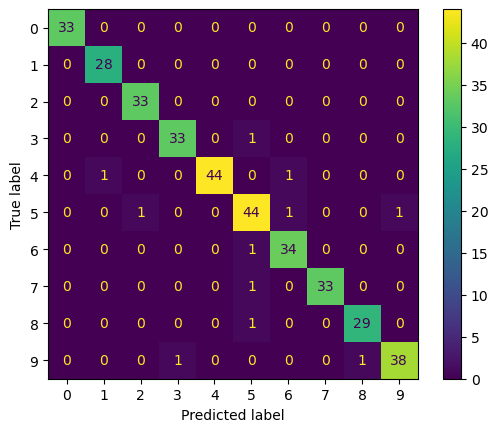

In [150]:
# Visualizing the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()

#### In multiclass classification, a confusion matrix helps you evaluate how well your model is predicting each class.
#### Each row shows how many times instances actually belonged to a class, 
#### while each column shows how many times they were predicted as a class.
#### Diagonal values from top-left to bottom shows correct prediction for each class.
### Few example to interprating the table
1. Row 0, actual class 0 : The model predicted 33 times correctly as class 0, and 0 wrong prediction on the remaining classes.
2. Row 4, actual class 4: The model predicted 44 times correctly as class 4, and 1 times wrongly as class 1 and class 6.
3. Row 9, actual class 9: The model predicted 38 times correctly as class 9, and 1 times wrongly as class 3 and class 8.
